In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import h3
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import Polygon

In [3]:
FIGURE_DIR = "../output/figures/maps"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

In [4]:
boundary_path = "/mnt/common-ssd/zadorzsofi/telekom/Breathing_city/data/budapest.geojson"

bp = gpd.read_file(boundary_path, engine="pyogrio")
bp = bp.to_crs(epsg=23700)

In [5]:
df = pd.read_pickle("../output/data/merged_analysis_data.pkl")

In [6]:
def h3_to_polygon(h3_id):
    boundary = h3.h3_to_geo_boundary(h3_id, geo_json=True)
    return Polygon(boundary)

df["geometry"] = df["raster_id"].apply(h3_to_polygon)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs(epsg=23700)

In [7]:
def plot_hex_map(gdf, column, vmin, vcenter, vmax, cmap, filename_stem, boundary=bp,
                  xlim=(640750, 675750), ylim=(221000, 256000)):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_axes([0, 0, 1, 1], frameon=False, xticks=[], yticks=[])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.margins(0)

    caxi = inset_axes(ax, width="2.5%", height="90%", loc=7, borderpad=3.8)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    gpd.clip(gdf, boundary.geometry.iloc[0]).plot(
        column=column,
        cmap=cmap,
        linewidth=0.2,
        norm=norm,
        ec="#2d2d2d",
        ax=ax,
        legend=True,
        cax=caxi,
    )

    cx.add_basemap(
        ax,
        crs=23700,
        source=cx.providers.CartoDB.PositronNoLabels,
        alpha=1,
        attribution=False,
    )
    boundary.plot(fc="none", ec="#2d2d2d", ax=ax)
    ax.axis("off")

    save_figure(filename_stem)
    plt.show()

# Company distribution (log-scaled)

In [22]:
colors = [
    "#6b200c",   "#973d21","#da6c42", "#ee956a", "#fbc2a9",
    '#FFFFFF', #"#f6f2ee",
    "#bad6f9", "#7db0ea", "#447fdd", "#225bb2", "#133e7e"
    ]
mycols = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

In [23]:
lincolors= [
  "#f6f2ee",
  "#d9e4f4",
  "#bad6f9",
  "#7db0ea",
  "#447fdd",
  "#225bb2",
  "#133e7e",
  "#0c3065"
]

lincols = LinearSegmentedColormap.from_list("custom_cmap", lincolors, N=256)

log(n_companies + 1) range: 0.69 to 4.97, median: 1.10


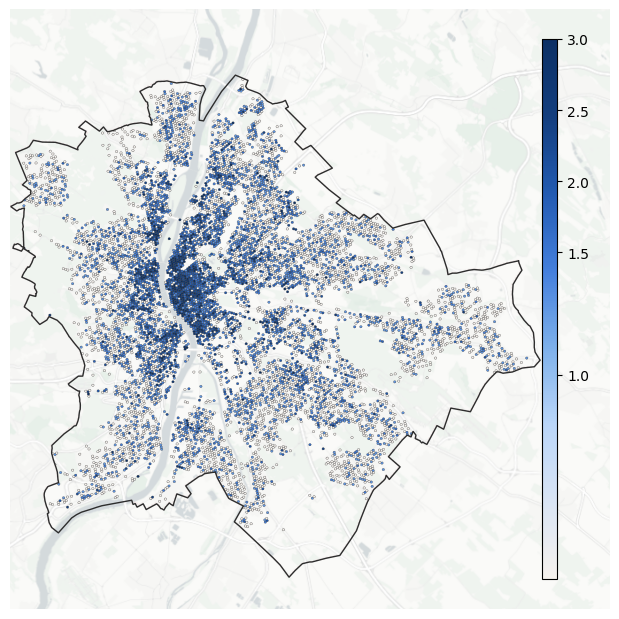

In [24]:
gdf["log_n_companies"] = np.log(gdf["n_companies"] + 1)

print(f"log(n_companies + 1) range: {gdf['log_n_companies'].min():.2f} to {gdf['log_n_companies'].max():.2f}, "
      f"median: {gdf['log_n_companies'].median():.2f}")

plot_hex_map(
    gdf, column="log_n_companies",
    vmin= gdf["log_n_companies"].min(),
    vcenter=gdf["log_n_companies"].median(),
    vmax=3, #gdf["log_n_companies"].max(),
    cmap=lincols,
    filename_stem="map_company_distribution_log",
)

# Workplace activity

loc_work_gaussian_opening range: 1.00 to 156.46, median: 5.19


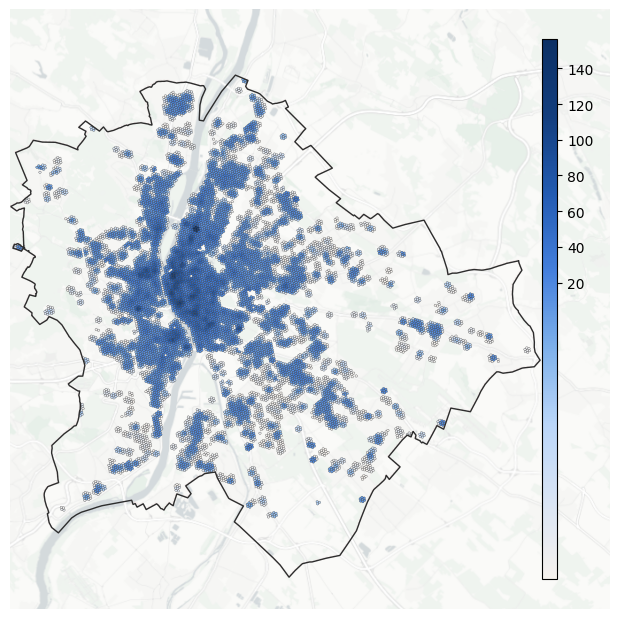

In [25]:
print(f"loc_work_gaussian_opening range: {gdf['loc_work_gaussian_opening'].min():.2f} to "
      f"{gdf['loc_work_gaussian_opening'].max():.2f}, median: {gdf['loc_work_gaussian_opening'].median():.2f}")

plot_hex_map(
    gdf, column="loc_work_gaussian_opening",
    vmin=gdf["loc_work_gaussian_opening"].min(),
    vcenter=gdf["loc_work_gaussian_opening"].median(),
    vmax=gdf["loc_work_gaussian_opening"].max(),
    cmap=lincols,
    filename_stem="map_workplace_activity",
)

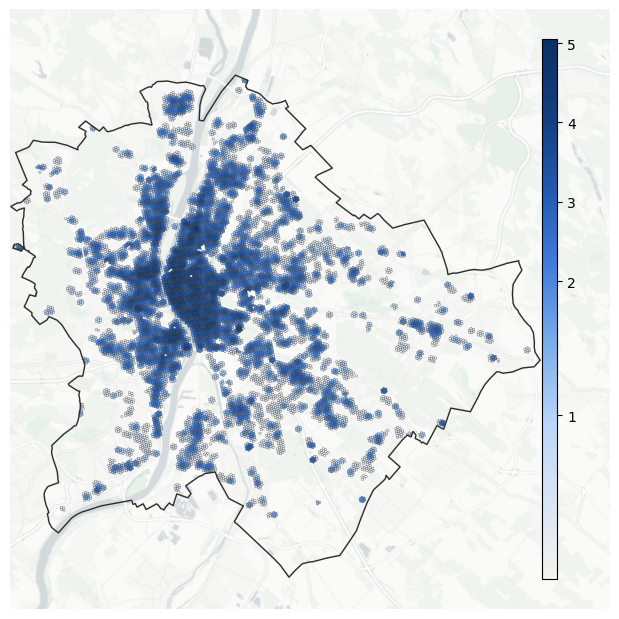

In [28]:
plot_hex_map(
    gdf, column="log_work_no0_opening",
    vmin=gdf["log_work_no0_opening"].min(),
    vcenter=gdf["log_work_no0_opening"].median(),
    vmax=gdf["log_work_no0_opening"].max(),
    cmap=lincols,
    filename_stem="map_log_workplace_activity",
)

# Workplace dependence


work_abs_diff range: -36.93 to 13.66


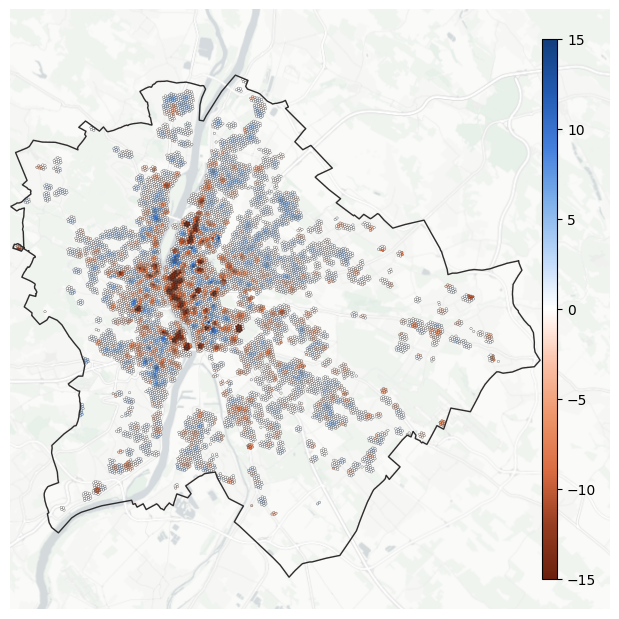

In [26]:
print(f"work_abs_diff range: {gdf['work_abs_diff'].min():.2f} to {gdf['work_abs_diff'].max():.2f}")

plot_hex_map(
    gdf, column="work_abs_diff",
    vmin=-15, #gdf["work_abs_diff"].min(),
    vcenter=0,
    vmax=15, #gdf["work_abs_diff"].max(),
    cmap=mycols,
    filename_stem="map_workplace_dependence",
)